In [29]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [30]:
class BMI(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    category : str

In [31]:
def Calculate_BMI (state:BMI) -> BMI :
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight / (height**2)

    state['bmi'] = round(bmi,2)

    return state

In [32]:
def cat(state: BMI) -> BMI:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = "Underweight"
    elif bmi < 25:
        state['category'] = "Normal weight"
    elif bmi < 30:
        state['category'] = "Overweight"
    else:
        state['category'] = "Obese"

    return state

In [33]:
# Define Graph
graph = StateGraph(BMI)

# Add nodes to graph
graph.add_node('Calculate_BMI',Calculate_BMI)
graph.add_node('BMI Category', cat )

graph.add_edge(START, 'Calculate_BMI')
graph.add_edge('Calculate_BMI','BMI Category')
graph.add_edge ('Calculate_BMI', END)

workflow = graph.compile()

In [34]:
initial_state = {'weight_kg': 80, 'height_m' : 1.73}
Final_State = workflow.invoke(initial_state)

print(Final_State)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


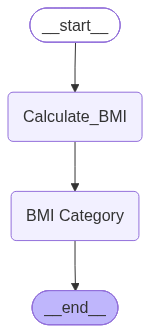

In [35]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))